# Unsupervised Learning

## Objective of performing unsupervised leaening

“The objective of unsupervised learning is to identify hidden patterns and group similar customers into clusters based on their characteristics, without using the target variable.”

## Loading Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage,dendrogram

In [5]:
df_churn=pd.read_csv("Churn_Processed.csv")

In [6]:
df=df_churn.copy()

## Removing Irrelevant Columns

In [7]:
df=df.drop('Churn Label',axis=1)
df=df.drop('Churn Value',axis=1)
df=df.drop('Churn Score',axis=1)
df=df.drop('CLTV',axis=1)
df=df.drop('Churn Reason',axis=1)

In [8]:
df.columns

Index(['Country', 'State', 'City', 'Zip Code', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Paperless Billing', 'Monthly Charges', 'Total Charges',
       'Multiple Lines_No phone service', 'Multiple Lines_Yes',
       'Internet Service_Fiber optic', 'Internet Service_No',
       'Online Security_No internet service', 'Online Security_Yes',
       'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

“Columns related to churn such as ‘Churn Label’, ‘Churn Value’, ‘Churn Score’, ‘CLTV’, and ‘Churn Reason’ are removed to ensure unbiased clustering, as unsupervised learning does not use target-related information.”

In [9]:
object_col=[col for col in df.columns if(df[col].dtype==object)]
print(object_col)

['Country', 'State', 'City']


In [10]:
df=df.drop(object_col,axis=1)

In [11]:
df=df.drop('Zip Code',axis=1)

In [12]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Paperless Billing', 'Monthly Charges',
       'Total Charges', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

Columns like 'Country','State','City' were removed because they were text and Unsupervised learning only works on numeric data types
Columns like 'Zip Code' were removed because they were not useful for Unsupervised Learning(Clustering)

In [13]:
df_unsuper=df.copy()

## Feature Scaling

In [14]:
scaler=StandardScaler()

In [15]:
X=df_unsuper
X_scaled=scaler.fit_transform(X)

## Model Selection

### K-Means Using Elbow Method

In [16]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(
        n_clusters=i,
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

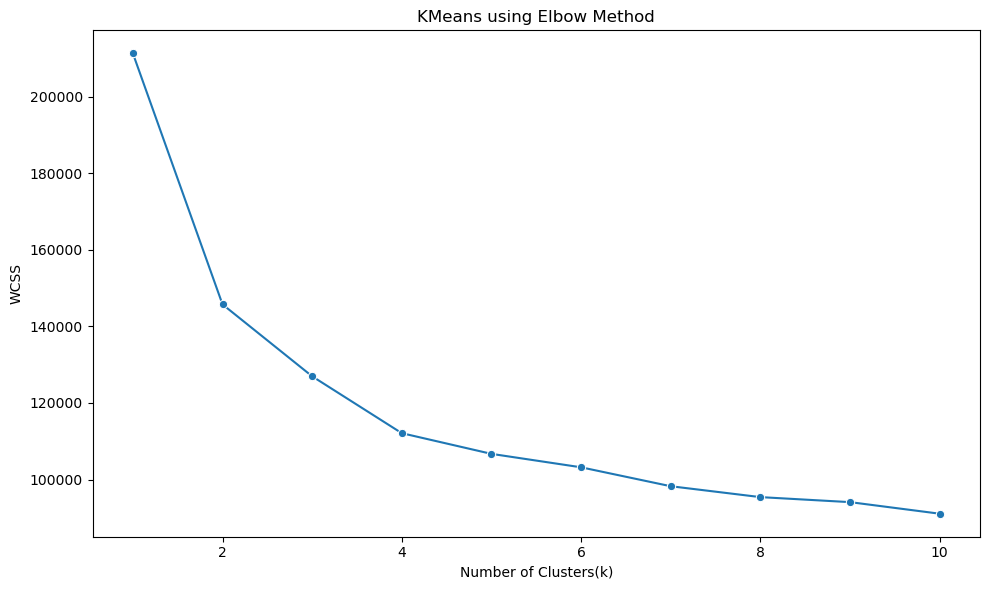

In [17]:
plt.figure(figsize=(10,6))
sns.lineplot(
    x=range(1,11),
    y=wcss,
    marker='o'
)
plt.xlabel('Number of Clusters(k)')
plt.ylabel('WCSS')
plt.title('KMeans using Elbow Method')
plt.tight_layout()
plt.show()

“From the Elbow Method graph, the optimal number of clusters is selected as K = 4, as it represents a clear point where the rate of decrease in WCSS begins to slow down, indicating diminishing returns with additional clusters.”

## K-Means Using Silhouette Score

In [18]:
for k in range(2,11):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42
    )
    labels=kmeans.fit_predict(X_scaled)
    score=silhouette_score(X_scaled,labels)
    print(f"k={k},Silhouette Score={score}")

k=2,Silhouette Score=0.3355698146336517
k=3,Silhouette Score=0.21814033783185935
k=4,Silhouette Score=0.23864049239501126
k=5,Silhouette Score=0.21777715786568677
k=6,Silhouette Score=0.15939142462008465
k=7,Silhouette Score=0.1382650362630921
k=8,Silhouette Score=0.13115087434690018
k=9,Silhouette Score=0.11635081212365736
k=10,Silhouette Score=0.12898240732525074


“Although the Elbow Method suggested a possible range of clusters around K = 4, the Silhouette Score analysis indicated that K = 2 provides the best cluster separation. Therefore, K = 2 is selected as the optimal number of clusters.”

## Making K-Means Model

In [19]:
kmeans=KMeans(
    n_clusters=2,
    random_state=42
)
cluster_2=kmeans.fit_predict(X_scaled)

In [29]:
df['KMeans_Cluster']=cluster_2

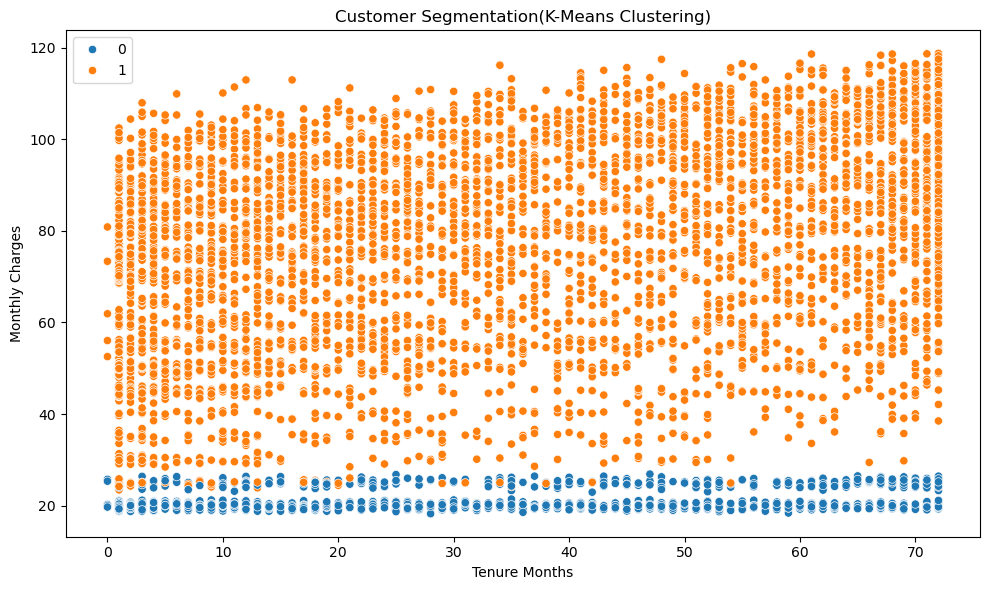

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_unsuper,
    x=df_unsuper['Tenure Months'],
    y=df_unsuper['Monthly Charges'],
    hue=cluster_2
)
plt.title('Customer Segmentation(K-Means Clustering)')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

In [21]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42
)
cluster_4=kmeans.fit_predict(X_scaled)

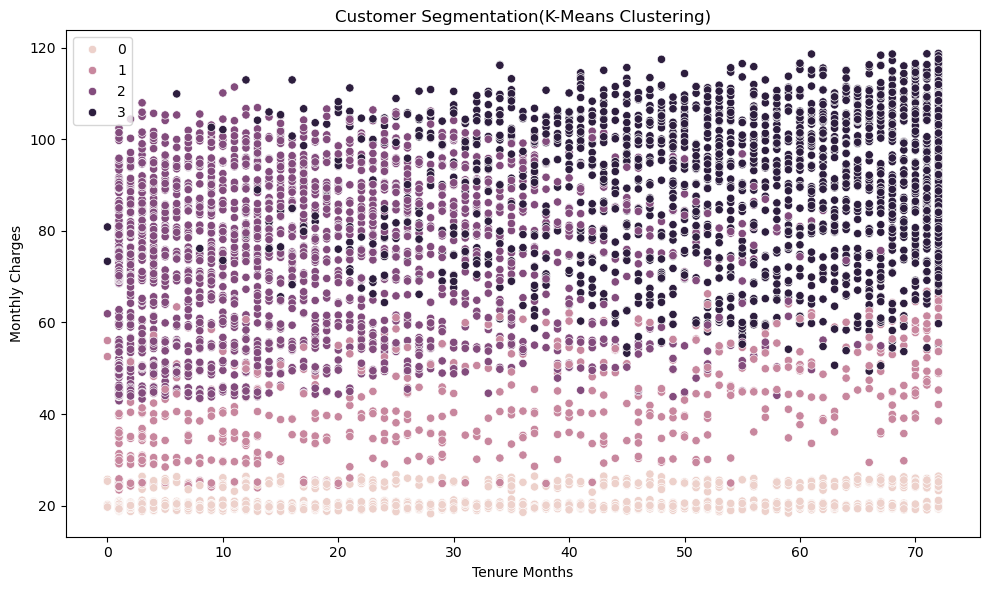

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_unsuper,
    x=df_unsuper['Tenure Months'],
    y=df_unsuper['Monthly Charges'],
    hue=cluster_4
)
plt.title('Customer Segmentation(K-Means Clustering)')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

“Although K = 2 yielded the highest Silhouette Score, it resulted in highly imbalanced clusters with most data points concentrated in a single cluster. Therefore, K = 4 is chosen as it provides more balanced and meaningful customer segmentation, making it more suitable for analysis."

### Hierarchial Clustering

In [23]:
Z=linkage(
    X_scaled,
    method='ward'
)

Text(0.5, 1.0, 'Dendogram for hierarchial clustering')

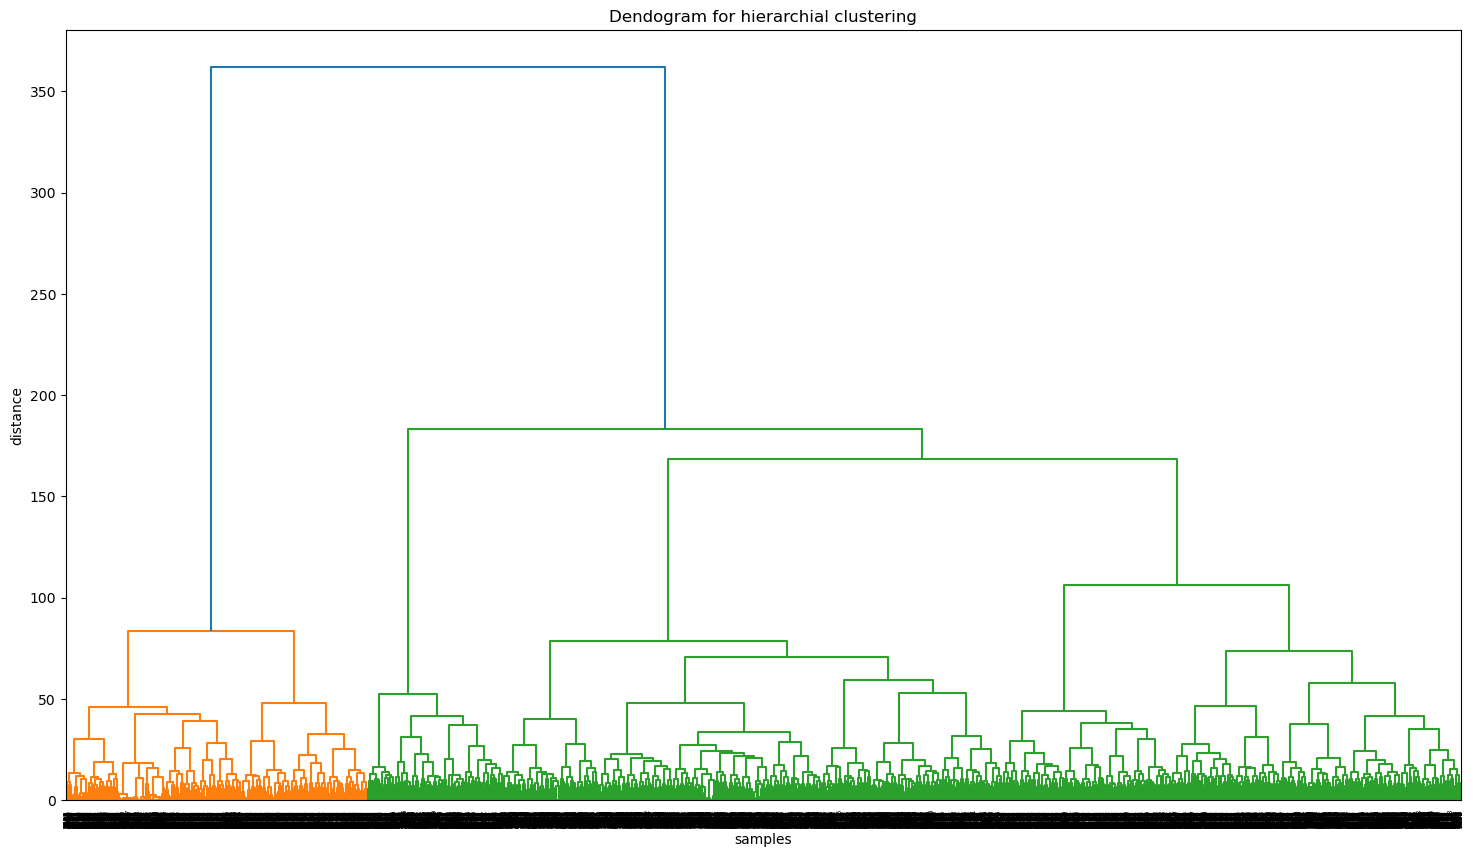

In [24]:
plt.figure(figsize=(18,10))
dendrogram(Z)
plt.xlabel('samples')
plt.ylabel('distance')
plt.title('Dendogram for hierarchial clustering')

In [27]:
agg=AgglomerativeClustering(
    n_clusters=2
)
labels=agg.fit_predict(X_scaled)

In [30]:
df['HC_Cluster']=labels

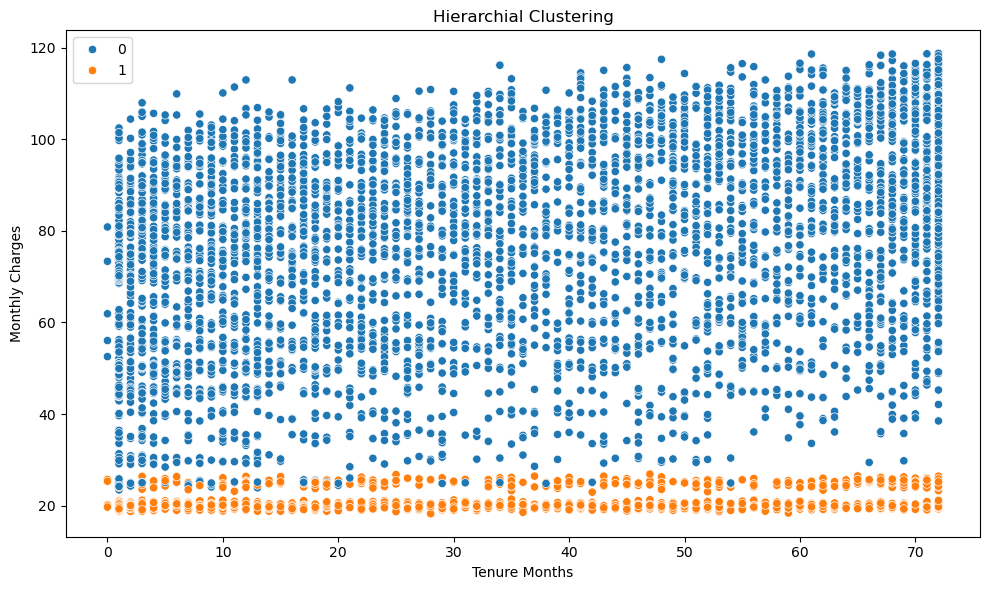

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_unsuper,
    x=df_unsuper['Tenure Months'],
    y=df_unsuper['Monthly Charges'],
    hue=labels
)
plt.title('Hierarchial Clustering')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

## Model Comparison

In [31]:
score_kmeans=silhouette_score(X_scaled,df['KMeans_Cluster'])
score_hc=silhouette_score(X_scaled,df['HC_Cluster'])

print("KMeans Score:",score_kmeans)
print("Hierarchial Clustering Score:",score_hc)

KMeans Score: 0.3355698146336517
Hierarchial Clustering Score: 0.3355698146336517


## Conclusion

“Unsupervised learning techniques were applied to identify hidden patterns in the dataset. K-Means and Hierarchical Clustering were used to segment customers, and both methods showed similar performance. Based on interpretability and clarity, K-Means was selected as the final model, successfully identifying meaningful customer segments.”